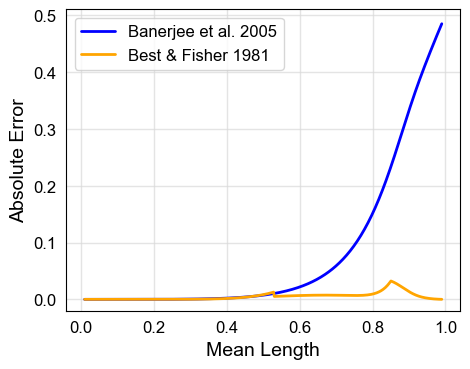

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import ive


# ---------------------------------------------------------
# Exact mean resultant length for the circular case m = 2:
#
#     A_2(kappa) = I_1(kappa) / I_0(kappa)
#
# ive is used instead of iv for better numerical stability.
# The exponential scaling cancels in the ratio.
# ---------------------------------------------------------
def A2(kappa):
    if kappa == 0:
        return 0.0

    return ive(1, kappa) / ive(0, kappa)


def A2_inverse_exact(r):
    """Numerically compute kappa satisfying A_2(kappa) = r."""
    if r == 0:
        return 0.0

    if not 0 < r < 1:
        raise ValueError("r must satisfy 0 <= r < 1.")

    # Find an upper bracket for the root.
    upper = 1.0
    while A2(upper) < r:
        upper *= 2.0

    return brentq(
        lambda kappa: A2(kappa) - r,
        0.0,
        upper,
        xtol=1e-12,
        rtol=1e-12,
    )


# ---------------------------------------------------------
# Banerjee et al. approximation
#
#     A_m^{-1}(r) ≈ r (m - r^2) / (1 - r^2)
#
# Here m = 2.
# ---------------------------------------------------------
def banerjee_inverse(r, m=2):
    return r * (m - r**2) / (1.0 - r**2)


# ---------------------------------------------------------
# Best and Fisher approximation for m = 2
# ---------------------------------------------------------
def best_fisher_inverse(r):
    r = np.asarray(r, dtype=float)
    result = np.empty_like(r)

    region_1 = r < 0.53
    region_2 = (r >= 0.53) & (r < 0.85)
    region_3 = r >= 0.85

    result[region_1] = (
        (5.0 / 6.0) * r[region_1] ** 5
        + r[region_1] ** 3
        + 2.0 * r[region_1]
    )

    result[region_2] = (
        1.39 * r[region_2]
        - 0.4
        + 0.43 / (1.0 - r[region_2])
    )

    result[region_3] = 1.0 / (
        r[region_3] ** 3
        - 4.0 * r[region_3] ** 2
        + 3.0 * r[region_3]
    )

    return result


# Avoid r = 1 because A_2^{-1}(r) diverges there.
mean_lengths = np.linspace(0.01, 0.99, 500)

# Numerical reference values.
exact_kappa = np.array(
    [A2_inverse_exact(r) for r in mean_lengths]
)

# Approximate values.
banerjee_kappa = banerjee_inverse(mean_lengths, m=2)
best_fisher_kappa = best_fisher_inverse(mean_lengths)

# Absolute approximation errors.
banerjee_error = np.abs(banerjee_kappa - exact_kappa)
best_fisher_error = np.abs(best_fisher_kappa - exact_kappa)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(4.8, 3.8))

fig.patch.set_facecolor("white")
fig.patch.set_alpha(1)
ax.set_facecolor("white")
ax.patch.set_alpha(1)
ax.grid(True, axis="both", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="black")
ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
for spine in ax.spines.values():
        spine.set_color("black")


ax.plot(
    mean_lengths,
    banerjee_error,
    linewidth=2,
    label="Banerjee et al. 2005",
    color="blue",
)

ax.plot(
    mean_lengths,
    best_fisher_error,
    linewidth=2,
    label="Best & Fisher 1981",
    color="orange",
)

ax.set_xlabel("Mean Length", fontsize=14)
ax.set_ylabel("Absolute Error", fontsize=14)

ax.set_xlim(-0.04, 1.04)
ax.set_ylim(-0.02, 0.51)

ax.set_xticks(np.arange(0.0, 1.01, 0.2))
ax.set_yticks(np.arange(0.0, 0.51, 0.1))

ax.grid(True, linewidth=1, alpha=0.7)
ax.legend(loc="upper left", fontsize=12, facecolor="white", labelcolor='black')

ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.savefig(
    "precision_error.pdf",
)
plt.show()
